# Homework 2

# Part 1: Expected Prediction Risk (EPR) 

The Expected Prediction Risk (EPR) is a fundamental concept that helps us measure how well our predictions match reality, accounting for all possible scenarios weighted by their probability of occurrence. Consider a supervised learning problem with a dataset $(x_i, y_i)_{i=1}^N$ where $x_i \in \mathbb{R}^d$ and $y_i$ are the labels (being them real numbers or categorical). We assume that the data is generated by a joint distribution, with density function $p(x,y)$. We fit a model $f(x)$ to this dataset. 

Given a measure of risk $L(y, f(x))$, the Expected Prediction Risk (EPR) is defined as:

$$\text{EPR}[f] = \mathbb{E}_{X,Y}[L(Y, f(X))]$$


First, let us consider the regression case.

Consider a dataset $\mathcal{D}_{regr} = (x_i, y_i)_{i=1}^N$ where $x_i \in \mathbb{R}^d$ and $y_i \in \mathbb{R}$.

We have seen in the class that in regression cases, the squared loss is a natural choice. Consider the squared loss function $L(y, f(x)) = (y - f(x))^2$. We define the Expected Prediction Risk (EPR) as:

$$\text{EPR}[f] = \mathbb{E}_{X,Y}[(Y - f(X))^2]$$

### **Q1**: Simplify the expression of the EPR(f) to obtain that the EPR is minimized by the conditional mean of Y given X.

▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣

$$
\mathrm{EPR}[f] \;=\; \mathbb{E}_{X,Y}\big[(Y - f(X))^2\big]
$$

$$
= \mathbb{E}_{X}\Big[\, \mathbb{E}_{Y\mid X}\big[(Y - f(X))^2 \mid X\big] \,\Big]
$$

Let $m(X)=\mathbb{E}[Y\mid X]$ (introduced only to simplify notation and keep the expressions short).

$$
\mathbb{E}_{Y\mid X}\big[(Y - f(X))^2 \mid X\big]
= \mathbb{E}_{Y\mid X}\big[(Y - m(X) + m(X) - f(X))^2 \mid X\big]
$$

$$
= \mathbb{E}_{Y\mid X}\big[(Y - m(X))^2 \mid X\big]
+ 2\,(m(X)-f(X))\, \mathbb{E}_{Y\mid X}\big[Y - m(X) \mid X\big]
+ (m(X)-f(X))^2
$$

The middle term is $0$ because, by definition of $m(X)$,
$$
\mathbb{E}_{Y\mid X}[Y - m(X)\mid X]
= \mathbb{E}[Y\mid X] - m(X)
= m(X) - m(X)
= 0.
$$

Therefore
$$
\mathbb{E}_{Y\mid X}\big[(Y - f(X))^2 \mid X\big]
= \operatorname{Var}(Y\mid X) + (m(X)-f(X))^2.
$$

So
$$
\mathrm{EPR}[f]
= \mathbb{E}_{X}\big[ \operatorname{Var}(Y\mid X) + (m(X)-f(X))^2 \big].
$$

The first term does not depend on $f$. The second term is $\ge 0$ and equals $0$ iff $f(X)=m(X)$ almost surely, since a square is nonnegative and is zero only when its argument is zero.

Therefore the minimizer is
$$
f^*(x)=\mathbb{E}[Y\mid X=x].
$$

And the minimal risk is
$$
\mathrm{EPR}[f^*]=\mathbb{E}_{X}\big[\operatorname{Var}(Y\mid X)\big].
$$

▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢


Let us consider now a categorical dataset. In order to highlight the difference with the regression case, we will use a different notation to highlight the difference: $\mathcal{D}_{class} = (x_i, c_i)_{i=1}^N$ where $x_i \in \mathbb{R}^d$ and $c_i \in \{1, \ldots, K\}$ is the true class of the $i$-th sample. We fit a model $\hat{c}(x){\in \{1, \ldots, K\}}$ to this dataset.

### **Q2** Write the expression of the EPR for the classification case simplified as much as possible for general risk functions.

▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣

$$
\mathrm{EPR}[\hat c] \;=\; \mathbb{E}_{X,C}\!\left[L\big(C,\hat c(X)\big)\right]
$$

$$
= \mathbb{E}_{X}\!\left[\, \mathbb{E}_{C\mid X}\!\left[L\big(C,\hat c(X)\big)\mid X\right] \right]
$$

Given $X$, the value $\hat c(X)$ is fixed (a deterministic label from the set $\{1, \ldots, K\}$). Therefore
$$
\mathbb{E}_{C\mid X}\!\left[L\big(C,\hat c(X)\big)\mid X\right]
= \sum_{k=1}^{K} L\!\left(k,\hat c(X)\right)\; \mathbb{P}(C=k\mid X).
$$

Hence
$$
\mathrm{EPR}[\hat c]
= \mathbb{E}_{X}\!\left[ \sum_{k=1}^{K} L\!\left(k,\hat c(X)\right)\; \mathbb{P}(C=k\mid X) \right].
$$

If $X$ is continuous, this is
$$
\mathrm{EPR}[\hat c]
= \int \left( \sum_{k=1}^{K} L\!\left(k,\hat c(x)\right)\; \mathbb{P}(C=k\mid x) \right)\, p_X(x)\, dx.
$$

If $X$ is discrete, this is
$$
\mathrm{EPR}[\hat c]
= \sum_{x} \left( \sum_{k=1}^{K} L\!\left(k,\hat c(x)\right)\; \mathbb{P}(C=k\mid x) \right)\, \mathbb{P}(X=x).
$$

▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢



### **Q3** Find the optimal classifier for 0-1 loss: $L(c, \hat{c}) = \mathbb{I}(c \neq \hat{c})$ known as the Bayes classifier.


▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣

We use the general classification EPR:
$$
\mathrm{EPR}[\hat c]
= \mathbb{E}_{X}\!\left[ \sum_{k=1}^{K} L\!\left(k,\hat c(X)\right)\, \mathbb{P}(C=k\mid X) \right].
$$

For $0$–$1$ loss $L(c,\hat c)=\mathbb{I}(c\neq \hat c)$ we have, for fixed $X$,
$$
\sum_{k=1}^{K} \mathbb{I}\big(k\neq \hat c(X)\big)\, \mathbb{P}(C=k\mid X)
= 1 - \mathbb{P}\!\left(C=\hat c(X)\mid X\right).
$$

Hence
$$
\mathrm{EPR}[\hat c]
= \mathbb{E}_{X}\!\left[\,1 - \mathbb{P}\!\left(C=\hat c(X)\mid X\right)\right].
$$

Minimizing the risk pointwise in $X$ is the same as maximizing the kept term $\mathbb{P}(C=\hat c(X)\mid X)$. Therefore the optimal rule (Bayes classifier) is
$$
\hat c^*(x) \in \arg\max_{k\in\{1,\ldots,K\}} \mathbb{P}(C=k\mid x).
$$

When there are ties, any tie-breaking among the maximizers gives the same risk. The minimal achievable risk (Bayes risk) is
$$
\mathrm{EPR}[\hat c^*]
= \mathbb{E}_{X}\!\left[\,1 - \max_{k} \mathbb{P}(C=k\mid X)\right].
$$

▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢


Let us apply these concepts to Gaussian Mixture Models. Let us fix the number of components $K=3$ and consider the following model for the joint distribution $p(x,c)$:

$$p(x|c_k) = \mathcal{N}(x|\mu_k, \Sigma_k)$$
$$p(c_k) = \pi_k$$
where $\pi_k$ are the probabilities of the different classes, $\mu_k$ are the means and $\Sigma_k$ are the covariance matrices of the $k$-th component.



### **Q4** Write a python function that generates samples from this model.



In [62]:
import numpy as np

def generate_samples_gauss_mix(pi, m, s, N):
    """
    Generate N samples from a 3-component Gaussian mixture model.

    Parameters:
    pi : array-like of length 3
        Class probabilities for each Gaussian component (must sum to 1).
    m : sequence of 3 array-like
        Means of the Gaussian components (each a 1D array-like).
    s : sequence of 3 array-like
        Covariance matrices (each a 2x2 array-like) for the Gaussian components.
    N : int
        Number of samples to generate.

    Returns:
    samples : ndarray of shape (N, d)
        Generated samples.
    labels : ndarray of shape (N,)
        Integer class labels in {0,1,2} for each sample.
    """
    pi = np.asarray(pi, dtype=float)
    if pi.shape != (3,):
        raise ValueError("pi must be array-like of length 3")
    if np.any(pi < 0):
        raise ValueError("All class probabilities must be >= 0")
    if not np.isclose(pi.sum(), 1.0):
        raise ValueError("Class probabilities must sum to 1")

    if not (len(m) == 3 and len(s) == 3):
        raise ValueError("Length of m and s must be 3")

    m_list = [np.asarray(mi) for mi in m]
    s_list = [np.asarray(si) for si in s]
    d = m_list[0].shape[0]
    samples = np.zeros((N, d))

    # draw class labels for all samples
    labels = np.random.choice(3, size=N, p=pi)

    # sample from each selected component
    for k in range(3):
        idx = (labels == k)
        nk = np.sum(idx)
        if nk > 0:
            samples[idx, :] = np.random.multivariate_normal(m_list[k], s_list[k], size=nk)

    return samples, labels


### **Q5** Take now 1000 samples from this model and plot them using matplotlib using the following choice for $\{\pi_k, \mu_k, \Sigma_k\}_{k=1}^3$: 

$$\pi = [0.3, 0.4, 0.3]$$

$$\mu_1 = \left[\begin{array}{c} 0 \\ 0 \end{array}\right], \mu_2 = \left[\begin{array}{c} 3 \\ 0 \end{array}\right], \mu_3 = \left[\begin{array}{c} 0 \\ 3 \end{array}\right]$$

$$\Sigma_1 = \left[\begin{array}{cc} 1 & 0 \\ 0 & 1 \end{array}\right], \Sigma_2 = \left[\begin{array}{cc} 1 & 0 \\ 0 & 1 \end{array}\right], \Sigma_3 = \left[\begin{array}{cc} 1 & 0 \\ 0 & 1 \end{array}\right]$$


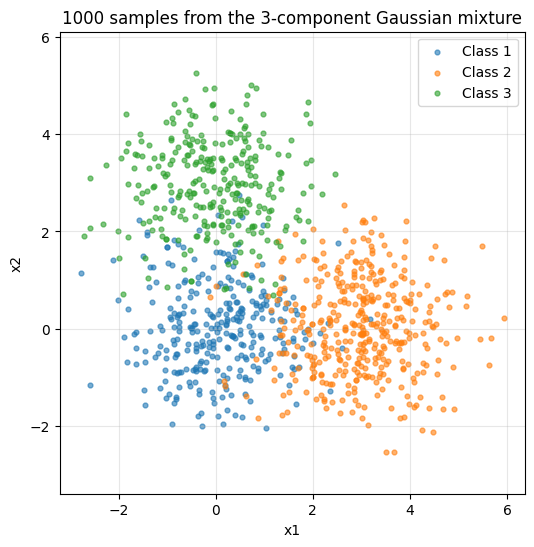

In [63]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

pi = [0.3, 0.4, 0.3]
m1 = np.array([0., 0.])
m2 = np.array([3., 0.])
m3 = np.array([0., 3.])
s1 = np.eye(2)
s2 = np.eye(2)
s3 = np.eye(2)

m = [m1, m2, m3]
s = [s1, s2, s3]

N = 1000
X, labels = generate_samples_gauss_mix(pi, m, s, N)

def plot_samples(X, labels):
    """
    Plot samples from a 3-component Gaussian mixture model.
    Parameters:
    X : ndarray of shape (N, d)
        Samples to plot.
    labels : ndarray of shape (N,)
        Integer class labels in {0,1,2} for each sample.    
    Returns:
    None
    """
    N = X.shape[0]
    plt.figure(figsize=(6,6))
    for k in range(3):
        idx = (labels == k)
        plt.scatter(X[idx, 0], X[idx, 1], s=12, label=f'Class {k+1}', alpha=0.6)

    plt.legend()
    plt.title(f"{N} samples from the 3-component Gaussian mixture")
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.xlabel('x1')
    plt.ylabel('x2')

plot_samples(X, labels)


We define the decision boundary between two classes $c_i$ and $c_j$ as the set of points where the posterior probability of the two classes is equal. Write the expression of the decision boundary for this model. 

### **Q6** Compute the posterior probabilities for this model.

▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣

We have a 3-component Gaussian mixture in $\mathbb{R}^2$ with priors $\pi=[0.3,0.4,0.3]$, means
$$
\mu_1=\begin{bmatrix}0\\0\end{bmatrix},\quad
\mu_2=\begin{bmatrix}3\\0\end{bmatrix},\quad
\mu_3=\begin{bmatrix}0\\3\end{bmatrix},
$$
and covariances $\Sigma_1=\Sigma_2=\Sigma_3=I_2$.

For any $x\in\mathbb{R}^2$, the posterior (responsibility) of component $k$ is
$$
p(k\mid x) \;=\; \frac{\pi_k\,\mathcal{N}(x\mid \mu_k, I_2)}{\sum_{j=1}^3 \pi_j\,\mathcal{N}(x\mid \mu_j, I_2)}.
$$

Since $\Sigma_k=I_2$ for all $k$, the Gaussian density is
$$
\mathcal{N}(x\mid \mu_k, I_2)
= \frac{1}{(2\pi)^{1}}\,\exp\!\left(-\tfrac{1}{2}\,\|x-\mu_k\|^2\right),
$$
and the common factor $(2\pi)^{-1}$ cancels between numerator and denominator. Therefore
$$
p(k\mid x) \;=\; \frac{\pi_k\,\exp\!\left(-\tfrac{1}{2}\,\|x-\mu_k\|^2\right)}
{\sum_{j=1}^3 \pi_j\,\exp\!\left(-\tfrac{1}{2}\,\|x-\mu_j\|^2\right)}.
$$

Writing this out for $x=(x_1,x_2)$,
$$
\begin{aligned}
p(1\mid x) &= \frac{0.3\,\exp\!\left(-\tfrac{1}{2}\big[(x_1-0)^2+(x_2-0)^2\big]\right)}
{Z(x)},\\[2mm]
p(2\mid x) &= \frac{0.4\,\exp\!\left(-\tfrac{1}{2}\big[(x_1-3)^2+(x_2-0)^2\big]\right)}
{Z(x)},\\[2mm]
p(3\mid x) &= \frac{0.3\,\exp\!\left(-\tfrac{1}{2}\big[(x_1-0)^2+(x_2-3)^2\big]\right)}
{Z(x)},
\end{aligned}
$$
where
$$
Z(x)=0.3\,e^{-\tfrac{1}{2}\big[(x_1-0)^2+(x_2-0)^2\big]}
+0.4\,e^{-\tfrac{1}{2}\big[(x_1-3)^2+(x_2-0)^2\big]}
+0.3\,e^{-\tfrac{1}{2}\big[(x_1-0)^2+(x_2-3)^2\big]}.
$$

These three posteriors sum to $1$ for every $x$.

▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢


### **Q7A** Compute analytically the decision boundary between class 1 and class 2.

▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣

We compare posteriors and set $p(1\mid x)=p(2\mid x)$.

$$
\frac{\pi_1\,\mathcal N(x\mid \mu_1,I_2)}{\sum_j \pi_j\,\mathcal N(x\mid \mu_j,I_2)}
=
\frac{\pi_2\,\mathcal N(x\mid \mu_2,I_2)}{\sum_j \pi_j\,\mathcal N(x\mid \mu_j,I_2)}
\ \Longleftrightarrow\
\pi_1\,\mathcal N(x\mid \mu_1,I_2)=\pi_2\,\mathcal N(x\mid \mu_2,I_2).
$$

With $\pi_1=0.3,\ \pi_2=0.4,\ \mu_1=(0,0)^\top,\ \mu_2=(3,0)^\top$, and $I_2$ for both covariances,
$$
0.3 \cdot \frac{1}{2\pi}\exp\!\left(-\tfrac12\big[x_1^2+x_2^2\big]\right)
=
0.4 \cdot \frac{1}{2\pi}\exp\!\left(-\tfrac12\big[(x_1-3)^2+x_2^2\big]\right).
$$

We mupltiply by $(2\pi)$ and take $\ln$ on both sides,
$$
\ln 0.3 - \tfrac12\big[x_1^2+x_2^2\big]
=
\ln 0.4 - \tfrac12\big[(x_1-3)^2+x_2^2\big].
$$

$$
-\tfrac12\Big(x_1^2+x_2^2-(x_1-3)^2-x_2^2\Big)=\ln\!\frac{0.4}{0.3}
$$

$$
x_1^2-(x_1-3)^2 = x_1^2-(x_1^2-6x_1+9)=6x_1-9
$$
$$
-\tfrac12(6x_1-9)=\ln\!\frac{4}{3}.
$$

Solve for $x_1$,
$$
-3x_1+4.5=\ln\!\frac{4}{3}
\quad\Longrightarrow\quad
x_1=\frac{4.5-\ln(4/3)}{3}\approx 1.4041.
$$

Therefore the decision boundary between class $1$ and class $2$ is the vertical line
$$
x_1=\frac{4.5-\ln(4/3)}{3},
$$
independent of $x_2$.

▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢


### **Q7B** Plot the optimal decision boundary for this model using the above calcultations. 


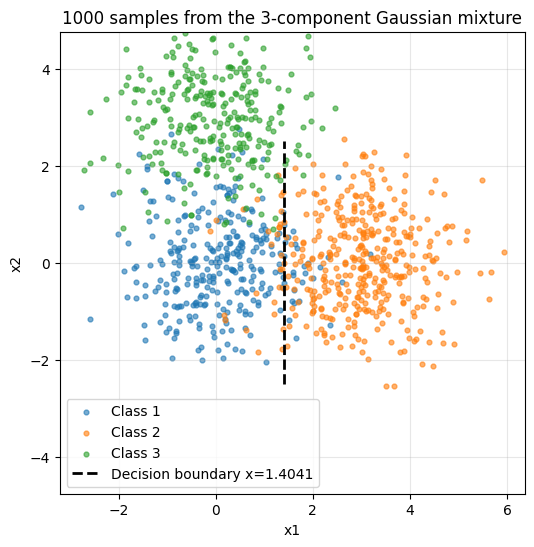

In [64]:
plot_samples(X, labels)
plt.plot([1.4041, 1.4041], [-2.5, 2.5], color='k', linestyle='--', linewidth=2, label='Decision boundary x=1.4041')
plt.ylim(-2.5, 2.5)
plt.legend()
plt.show()

### **Q8** Compute the error of the Bayes classifier on the dataset in Q5 as measured by the misclassification rate.


In [66]:
def apost(x, pi, m, s):
        return -0.5 * (x - m).T @ np.linalg.inv(s) @ (x - m) + np.log(pi)  

def predict_from_gauss_mix(X, pi, m, s):
    """
    Generate N samples from a 3-component Gaussian mixture model.

    Parameters:
    X samples to classify    

    pi : array-like of length 3
        Class probabilities for each Gaussian component (must sum to 1).
    m : sequence of 3 array-like
        Means of the Gaussian components (each a 1D array-like).
    s : sequence of 3 array-like
        Covariance matrices (each a 2x2 array-like) for the Gaussian components.

    Returns:
    samples : ndarray of shape (N, d)
        Generated samples.
    labels : ndarray of shape (N,)
        Integer class labels in {0,1,2} for each sample.
    """
    pi = np.asarray(pi, dtype=float)
    if pi.shape != (3,):
        raise ValueError("pi must be array-like of length 3")
    if np.any(pi < 0):
        raise ValueError("All class probabilities must be >= 0")
    if not np.isclose(pi.sum(), 1.0):
        raise ValueError("Class probabilities must sum to 1")

    if not (len(m) == 3 and len(s) == 3):
        raise ValueError("Length of m and s must be 3")

    m_list = [np.asarray(mi) for mi in m]
    s_list = [np.asarray(si) for si in s]
    d = m_list[0].shape[0]

    

    predictions = np.zeros(X.shape[0], dtype=int)
    for i in range(X.shape[0]): 
        scores = [apost(X[i], pi[k], m_list[k], s_list[k]) for k in range(3)]
        predictions[i] = np.argmax(scores)

    return predictions

Classification error (Error of the Bayes classifier): 9.50%


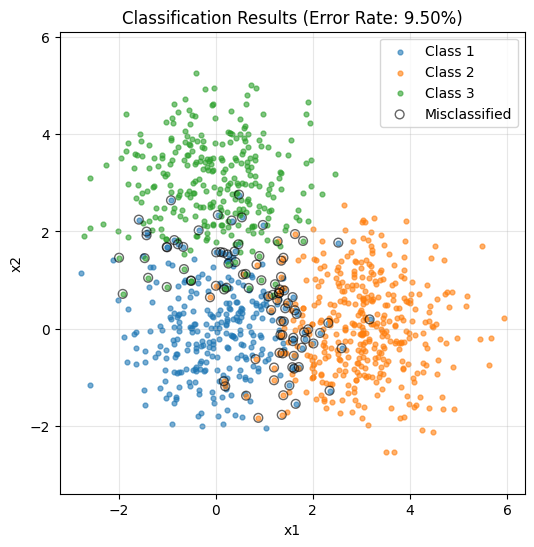

In [67]:
predictions = predict_from_gauss_mix(X, pi, m, s)
err = np.mean(predictions != labels)
print(f"Classification error (Error of the Bayes classifier): {err*100:.2f}%")

plot_samples(X, labels)

X_misclassified = X[predictions != labels]
X_misclassified = X[predictions != labels]
plt.scatter(X_misclassified[:, 0], X_misclassified[:, 1], facecolors='none', edgecolors='black', 
            s=40, label='Misclassified', alpha=0.6)
plt.title(f'Classification Results (Error Rate: {err*100:.2f}%)')
plt.legend()
plt.show()

Consider now the case where the covariance matrices are different. Take the following choice for $\{\pi_k, \mu_k, \Sigma_k\}_{k=1}^3$: 

$$\pi = [\pi_1=0.3, \pi_2=0.4, \pi_3=0.3]$$

$$\mu_1 = \left[\begin{array}{c} 0 \\ 0 \end{array}\right], \mu_2 = \left[\begin{array}{c} 3 \\ 0 \end{array}\right], \mu_3 = \left[\begin{array}{c} 0 \\ 3 \end{array}\right]$$

$$\Sigma_1 = \left[\begin{array}{cc} 1 & 0 \\ 0 & 1 \end{array}\right], \Sigma_2 = \left[\begin{array}{cc} 2 & 0 \\ 0 & 2 \end{array}\right], \Sigma_3 = \left[\begin{array}{cc} 1 & 0.5 \\ 0.5 & 1 \end{array}\right]$$

### **Q9** What is the decision boundary between class 1 and class 2 in this case?
Note: a fully analytical or functional solution might be difficult to obtain; only an interpretable and practical solution for plotting is required.


▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣

We set $p(1\mid x)=p(2\mid x)$ and use Gaussian class-conditionals:
$$
\pi_1\,\mathcal N(x\mid \mu_1,\Sigma_1)=\pi_2\,\mathcal N(x\mid \mu_2,\Sigma_2).
$$

Take $\ln$ and plug the model parameters
$$
\ln\pi_1-\tfrac12\ln|\Sigma_1|-\tfrac12(x-\mu_1)^\top\Sigma_1^{-1}(x-\mu_1)
=
\ln\pi_2-\tfrac12\ln|\Sigma_2|-\tfrac12(x-\mu_2)^\top\Sigma_2^{-1}(x-\mu_2),
$$
with $\pi_1=0.3,\ \pi_2=0.4,\ \mu_1=\begin{bmatrix}0\\0\end{bmatrix},\ \mu_2=\begin{bmatrix}3\\0\end{bmatrix},\ \Sigma_1=I_2,\ \Sigma_2=2I_2$.

Compute determinants and inverses
$$
|\Sigma_1|=1,\quad \Sigma_1^{-1}=I_2,\qquad
|\Sigma_2|=4,\quad \Sigma_2^{-1}=\tfrac12 I_2.
$$

Write $x=(x_1,x_2)$ and expand the quadratic forms
$$
(x-\mu_1)^\top\Sigma_1^{-1}(x-\mu_1)=x_1^2+x_2^2,
$$
$$
(x-\mu_2)^\top\Sigma_2^{-1}(x-\mu_2)
=\tfrac12\big[(x_1-3)^2+x_2^2\big].
$$

Substitute these into the equality
$$
\ln 0.3-\tfrac12\ln 1-\tfrac12(x_1^2+x_2^2)
=
\ln 0.4-\tfrac12\ln 4-\tfrac12\cdot\tfrac12\big[(x_1-3)^2+x_2^2\big],
$$
i.e.
$$
\ln 0.3-\tfrac12(x_1^2+x_2^2)
=
\ln 0.4-\tfrac12\ln 4-\tfrac14\big[(x_1-3)^2+x_2^2\big].
$$

Move all terms to the left
$$
\big(\ln 0.3-\ln 0.4+\tfrac12\ln 4\big)
-\tfrac12(x_1^2+x_2^2)
+\tfrac14\big[(x_1-3)^2+x_2^2\big]
=0.
$$

Simplify the constant term
$$
\ln 0.3-\ln 0.4+\tfrac12\ln 4
=\ln\!\frac{0.3}{0.4}+\ln 2
=\ln\!\frac{0.6}{0.4}
=\ln\!\frac{3}{2}.
$$

Expand and collect the quadratic terms
$$
-\tfrac12(x_1^2+x_2^2)+\tfrac14\big[(x_1-3)^2+x_2^2\big]
=-\tfrac14(x_1^2+x_2^2)-\tfrac32 x_1+\tfrac94.
$$

Combine everything
$$
\ln\!\frac{3}{2}\;-\;\tfrac14(x_1^2+x_2^2)\;-\;\tfrac32 x_1\;+\;\tfrac94\;=\;0.
$$

Multiply by $4$
$$
4\ln\!\frac{3}{2}\;-\;(x_1^2+x_2^2)\;-\;6x_1\;+\;9\;=\;0.
$$

Rearrange and complete the square in $x_1$
$$
x_1^2+6x_1+x_2^2-9-4\ln\!\frac{3}{2}=0
\;\Longleftrightarrow\;
(x_1+3)^2+x_2^2=18+4\ln\!\frac{3}{2}.
$$

Decision boundary between class $1$ and class $2$:
$$
(x_1+3)^2+x_2^2=18+4\ln\!\frac{3}{2},
$$
a circle with center $(-3,0)$ and radius $\sqrt{\,18+4\ln(3/2)\,}$.

▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢▢


### **Q10** Plot the decision boundary for this model and discuss the difference with the previous case (if any).



In [70]:
def plot_decision_boundary(X, dims, pi, m, s, classes):
    """
    Plot decision boundary between classes classes[0] and classes[1] for the 3-component Gaussian mixture model.
    """
    N = X.shape[0]
    x_dim = dims[0]
    y_dim = dims[1]
    
    ind1 = classes[0] - 1
    ind2 = classes[1] - 1
    pi_list = [pi[ind1], pi[ind2]]
    m_list = [m[ind1], m[ind2]]
    s_list = [s[ind1], s[ind2]]

    predictions = np.zeros(X.shape[0], dtype=int)

    for i in range(N):
        scores = [apost(X[i], pi_list[k], m_list[k], s_list[k]) for k in range(2)]
        predictions[i] = np.argmax(scores)
    Z = predictions.reshape(y_dim, x_dim)
    plt.contourf(X[:, 0].reshape(y_dim, x_dim), X[:, 1].reshape(y_dim, x_dim), Z, alpha=0.3)
    plt.title(f'Decision Boundary between Class {classes[0]} and Class {classes [1]}')



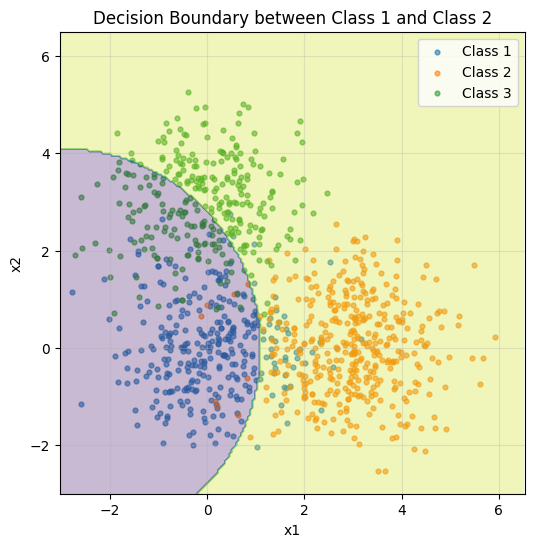

In [71]:
pi = [0.3, 0.4, 0.3]
m1 = np.array([0., 0.])
m2 = np.array([3., 0.])
m3 = np.array([0., 3.])
s1 = np.eye(2)
s2 = 2*np.eye(2)
s3 = np.array([[1, 0.5], [0.5, 1]])

m = [m1, m2, m3]
s = [s1, s2, s3]

precision = 200
x = np.linspace(-3, 6.5, precision)
y = np.linspace(-3, 6.5, precision)
X_grid, Y_grid = np.meshgrid(x, y)
grid_points = np.column_stack([X_grid.ravel(), Y_grid.ravel()])
plot_samples(X, labels)
plot_decision_boundary(grid_points, (precision, precision), pi, m, s, (1, 2))






### **Q11** Sample 1000 points from the heterogeneous model defined after Q8 and plot them. 

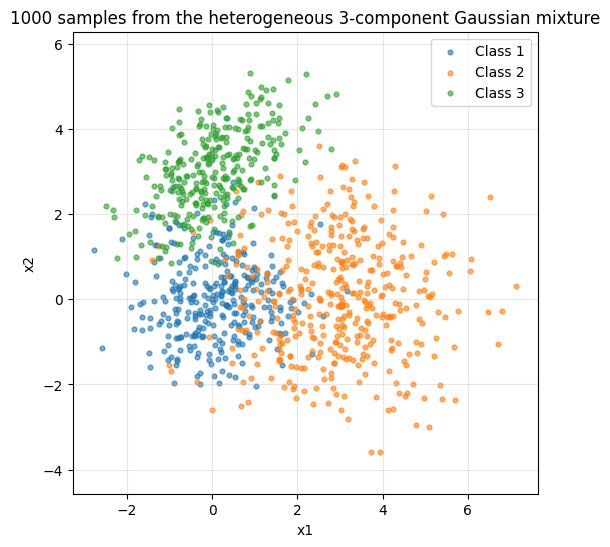

In [ ]:
np.random.seed(0)

N = 1000
X, labels = generate_samples_gauss_mix(pi, m, s, N)

plt.figure(figsize=(6,6))
for k in range(3):
    idx = (labels == k)
    plt.scatter(X[idx, 0], X[idx, 1], s=12, label=f'Class {k+1}', alpha=0.6)

plt.legend()
plt.title('1000 samples from the heterogeneous 3-component Gaussian mixture')
plt.xlabel('x1')
plt.ylabel('x2')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

### **Q12** Compute the error of the Bayes classifier on this dataset.

Classification error (Error of the Bayes classifier): 10.60%


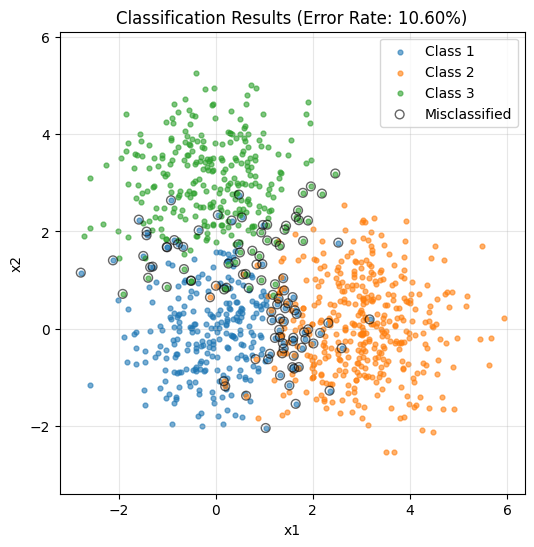

In [72]:
predictions = predict_from_gauss_mix(X, pi, m, s)
err = np.mean(predictions != labels)
print(f"Classification error (Error of the Bayes classifier): {err*100:.2f}%")

plot_samples(X, labels)

X_misclassified = X[predictions != labels]
X_misclassified = X[predictions != labels]
plt.scatter(X_misclassified[:, 0], X_misclassified[:, 1], facecolors='none', edgecolors='black', 
            s=40, label='Misclassified', alpha=0.6)
plt.title(f'Classification Results (Error Rate: {err*100:.2f}%)')
plt.legend()
plt.show()